# Proyek Analisis Data: Brazilian E-Commerce Public Dataset by Olist
- **Nama:** Chairun Nisaq
- **Email:** Chairunnisaq11@gmail.com
- **ID Dicoding:** chairun_nisaq

## Menentukan Pertanyaan Bisnis

1. Bagaimana distribusi kontribusi revenue pelanggan selama periode 2017-2018, serta berapa persentase kontribusi pelanggan teratas (Top 10 dan Top 100) terhadap total revenue?
2. Bagaimana tren revenue bulanan selama periode 2016-2018, serta pada bulan apa terjadi peak revenue dan lowest revenue?
3. Bagaimana distribusi pelanggan ke dalam segmen RFM (Champions, Loyal, At Risk, dll) selama periode 2017-2018, serta segmen mana yang memberikan kontribusi revenue terbesar?

## Import Semua Packages/Library yang Digunakan

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import datetime as dt

sns.set(style='darkgrid')

## Data Wrangling

### Gathering Data

In [54]:
from google.colab import drive
drive.mount('/content/drive')
orders = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Analisis Data DBS/olist_orders_dataset.csv')
customers = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Analisis Data DBS/olist_customers_dataset.csv')
order_items = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Analisis Data DBS/olist_order_items_dataset.csv')
payments = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Analisis Data DBS/olist_order_payments_dataset.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [55]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [56]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [57]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [58]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


**Insight:**

Dataset yang digunakan adalah Brazilian E-Commerce Dataset dari Olist yang diperoleh melalui Kaggle. Dataset ini terdiri dari beberapa tabel seperti orders, customers, order_items, dan payments.


### Assessing Data

In [59]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [60]:
orders.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [61]:
print("Jumlah duplikasi: ", orders.duplicated().sum())

Jumlah duplikasi:  0


In [62]:
orders.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [63]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [64]:
customers.isna().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [65]:
print("Jumlah duplikasi: ", customers.duplicated().sum())

Jumlah duplikasi:  0


In [66]:
customers.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [67]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [68]:
order_items.isna().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [69]:
print("Jumlah Duplikasi: ", order_items.duplicated().sum())

Jumlah Duplikasi:  0


In [70]:
order_items.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [71]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [72]:
payments.isna().sum()

,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


In [73]:
print("Jumlah Duplikasi: ", payments.duplicated().sum())

Jumlah Duplikasi:  0


In [74]:
payments.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


**Insight:**
- Dataset orders memiliki beberapa missing values pada kolom delivery seperti `order_delivered_customer_date`, yang menunjukkan tidak semua pesanan berhasil dikirim.
- Tidak ditemukan data duplikat pada dataset orders, customers, order_items, maupun payments.
- Semua dataset memiliki struktur data yang cukup lengkap untuk dianalisis lebih lanjut.

### Cleaning Data

In [75]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

In [76]:
orders = orders[orders['order_status'] == 'delivered']

orders.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,14
order_delivered_carrier_date,2
order_delivered_customer_date,8
order_estimated_delivery_date,0


In [77]:
orders.dropna(inplace=True)

In [78]:
# Merge dataset
df = orders.merge(customers, on='customer_id')
df = df.merge(order_items, on='order_id')
df = df.merge(payments, on='order_id')

# Hilangkan invalid data
df = df[df['payment_value'] > 0]

In [79]:
# Time features
df['month'] = df['order_purchase_timestamp'].dt.to_period('M')
df['year'] = df['order_purchase_timestamp'].dt.year
df['day_of_week'] = df['order_purchase_timestamp'].dt.day_name()

# Revenue
df['total_price'] = df['price'] + df['freight_value']

# Delivery
df['delivery_time'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days

# Customer segmentation
customer_spending = df.groupby('customer_unique_id')['payment_value'].sum()

customer_category = pd.cut(
    customer_spending,
    bins=[0,100,500,1000,5000],
    labels=['Low','Medium','High','VIP']
)


In [80]:
df.describe()

,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code_prefix,order_item_id,price,freight_value,payment_sequential,payment_installments,payment_value,year,total_price,delivery_time
count,115007,115007,115007,115007.000000,115007.000000,115007.000000,115007.000000,115007.000000,115007.000000,115007.000000,115007.000000,115007.000000,115007.000000
mean,2017-12-31 20:49:26.793864704,2018-01-13 08:24:55.570383104,2018-01-24 16:40:27.817437184,35081.962437,1.196414,120.082993,19.995895,1.090612,2.937056,171.924369,2017.540993,140.078888,12.017399
min,2016-10-03 09:44:50,2016-10-11 13:46:32,2016-10-27 00:00:00,1003.000000,1.000000,0.850000,0.000000,1.000000,0.000000,0.010000,2016.000000,6.080000,0.000000
25%,2017-09-13 08:40:33,2017-09-25 15:36:00,2017-10-04 00:00:00,11310.000000,1.000000,39.900000,13.080000,1.000000,1.000000,60.850000,2017.000000,55.230000,6.000000
50%,2018-01-19 13:10:46,2018-02-01 19:36:05,2018-02-15 00:00:00,24320.000000,1.000000,74.900000,16.280000,1.000000,2.000000,108.190000,2018.000000,91.880000,10.000000
75%,2018-05-04 16:54:30,2018-05-15 16:55:48.500000,2018-05-28 00:00:00,58803.000000,1.000000,133.000000,21.180000,1.000000,4.000000,188.940000,2018.000000,157.300000,15.000000
max,2018-08-29 15:00:37,2018-10-17 13:22:46,2018-10-25 00:00:00,99980.000000,21.000000,6735.000000,409.680000,26.000000,24.000000,13664.080000,2018.000000,6929.310000,209.000000
std,NaN,NaN,NaN,29851.934650,0.699436,183.046429,15.744834,0.684257,2.772557,266.135719,0.504061,190.108067,9.458881


In [81]:
df = df[df['delivery_time'] < 30]

In [90]:
df.to_csv('main_data.csv', index=False)

**Insight:**
- Data telah dibersihkan dengan memfilter hanya pesanan berstatus "delivered" untuk memastikan analisis hanya mencakup transaksi yang valid.
- Missing values yang tersisa sangat kecil dan dihapus untuk menjaga kualitas data.
- Feature engineering dilakukan dengan menambahkan informasi waktu seperti bulan dan hari untuk analisis tren.
- Fitur delivery_time menunjukkan durasi pengiriman yang dapat digunakan untuk mengevaluasi performa logistik.
- Fitur total_price digunakan untuk merepresentasikan total nilai transaksi termasuk ongkir.
- Distribusi nilai transaksi (payment_value) tidak merata dan cenderung skewed ke kanan, menunjukkan adanya pelanggan dengan nilai transaksi yang sangat tinggi.
- Rata-rata waktu pengiriman adalah sekitar 10–12 hari atau paling lama 30 hari, oleh karena itu saya menghapus outlier dengan durasi pengiriman yang sangat lama.
- Sebagian besar pelanggan hanya membeli satu item per transaksi, terlihat dari median order_item_id sebesar 1.
- Nilai ongkos kirim relatif kecil dibandingkan harga produk, namun terdapat beberapa nilai ekstrem.
- Aktivitas transaksi paling banyak terjadi pada tahun 2017–2018

## Exploratory Data Analysis (EDA)

### Explore Sales Trend

In [82]:
monthly_sales = df.groupby('month')['payment_value'].sum()
monthly_sales.index = monthly_sales.index.astype(str)

# Peak & lowest
peak_month = monthly_sales.idxmax()
lowest_month = monthly_sales.idxmin()

peak_value = monthly_sales.max()
lowest_value = monthly_sales.min()


Penjualan menunjukkan tren peningkatan signifikan dari tahun 2016 hingga 2018. Berdasarkan perhitungan, puncak penjualan terjadi pada peak_month, sedangkan titik terendah terjadi pada lowest_month. Hal ini menunjukkan adanya pola musiman, di mana penjualan meningkat pada periode tertentu.

### Explore Top Customer

In [83]:
df_filtered = df[(df['year'] >= 2017) & (df['year'] <= 2018)]

customer_revenue = (
    df_filtered.groupby('customer_unique_id')['payment_value']
    .sum()
    .sort_values(ascending=False)
)

total_revenue = customer_revenue.sum()

# Kontribusi %
customer_revenue_pct = (customer_revenue / total_revenue) * 100

top10_contribution = customer_revenue_pct.head(10).sum()
top100_contribution = customer_revenue_pct.head(100).sum()

print(f"Top 10 customers: {top10_contribution:.2f}%")
print(f"Top 100 customers: {top100_contribution:.2f}%")

cumulative_pct = customer_revenue_pct.cumsum()

# berapa customer untuk 80%
pareto_cutoff = (cumulative_pct <= 80).sum()

print(f"{pareto_cutoff} customers contribute ~80% of revenue")



Top 10 customers: 2.06%
Top 100 customers: 6.20%
37229 customers contribute ~80% of revenue


Distribusi kontribusi revenue pelanggan menunjukkan bahwa tidak terdapat konsentrasi yang tinggi pada pelanggan tertentu. Top 10 pelanggan hanya menyumbang sekitar 2.06% dari total revenue, sementara Top 100 pelanggan hanya berkontribusi sebesar 6.20%. Untuk mencapai sekitar 80% dari total revenue, dibutuhkan lebih dari 37.000 pelanggan. Hal ini menunjukkan bahwa revenue tersebar secara luas di antara pelanggan. Dengan demikian, performa bisnis lebih bergantung pada banyak pelanggan dengan kontribusi kecil dibandingkan pada segelintir pelanggan bernilai tinggi.


# **RFM**

In [92]:
df_rfm_base = df[(df['year'] >= 2017) & (df['year'] <= 2018)].copy()

snapshot_date = df_rfm_base['order_purchase_timestamp'].max() + pd.Timedelta(days=1)


rfm = df_rfm_base.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique',
    'payment_value': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm['R_score'] = pd.qcut(
    rfm['Recency'],
    5,
    labels=[5,4,3,2,1],
    duplicates='drop'
)

rfm['F_score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5],
    duplicates='drop'
)

rfm['M_score'] = pd.qcut(
    rfm['Monetary'],
    5,
    labels=[1,2,3,4,5],
    duplicates='drop'
)

# Convert ke int (biar bisa dibandingkan)
rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)

# segmentasi customer
def segment_customer(row):
    if row['R_score'] == 5 and row['F_score'] == 5 and row['M_score'] == 5:
        return 'Champions'
    elif row['F_score'] >= 4 and row['M_score'] >= 4:
        return 'Loyal Customers'
    elif row['R_score'] >= 4:
        return 'Recent Customers'
    elif row['R_score'] <= 2:
        return 'At Risk'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# distribusi segment
segment_counts = rfm['Segment'].value_counts()

print("Customer Distribution:")
print(segment_counts)

# merge data
rfm_reset = rfm.reset_index()

df_rfm = df_rfm_base.merge(
    rfm_reset[['customer_unique_id', 'Segment']],
    on='customer_unique_id'
)

# revenue per segment
segment_revenue = df_rfm.groupby('Segment')['payment_value'].sum()

print("\nRevenue per Segment:")
print(segment_revenue)

rfm.head()


Customer Distribution:
Segment
At Risk             29742
Recent Customers    29473
Others              14709
Loyal Customers     13951
Champions             919
Name: count, dtype: int64

Revenue per Segment:
Segment
At Risk             5143294.88
Champions            623998.86
Loyal Customers     5644368.36
Others              2222313.72
Recent Customers    5002140.67
Name: payment_value, dtype: float64


,Recency,Frequency,Monetary,R_score,F_score,M_score,Segment
customer_unique_id,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,Recent Customers
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,Recent Customers
0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,At Risk
0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,At Risk
0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,At Risk


## Visualization & Explanatory Analysis

### Pertanyaan 1:

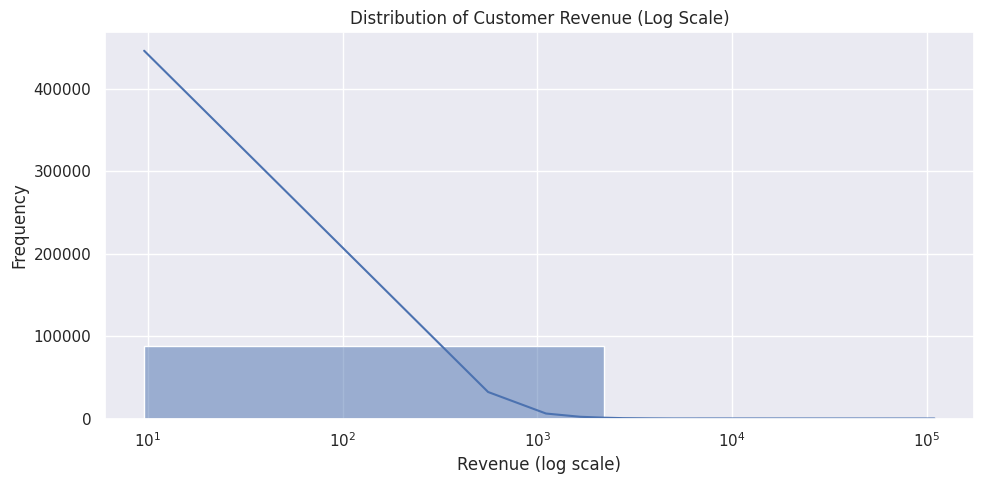

In [85]:
plt.figure(figsize=(10,5))
sns.histplot(customer_revenue, bins=50, kde=True)

plt.xscale('log')
plt.title("Distribution of Customer Revenue (Log Scale)")
plt.xlabel("Revenue (log scale)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


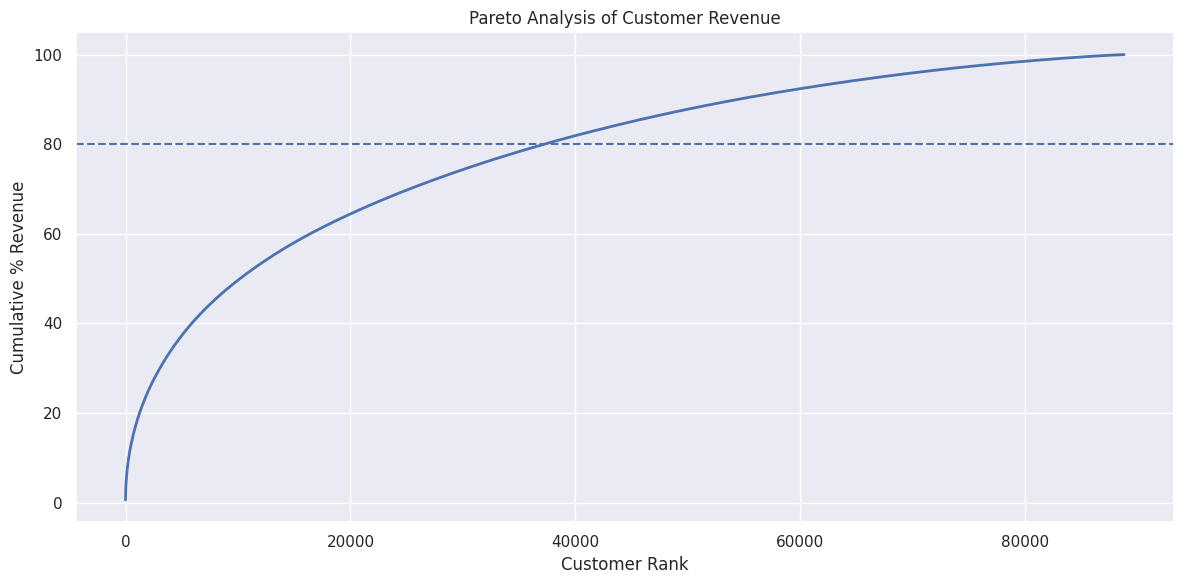

In [86]:
plt.figure(figsize=(12,6))

plt.plot(cumulative_pct.values, linewidth=2)

# garis 80%
plt.axhline(y=80, linestyle='--')

plt.title("Pareto Analysis of Customer Revenue")
plt.xlabel("Customer Rank")
plt.ylabel("Cumulative % Revenue")

plt.tight_layout()
plt.show()

Distribusi revenue pelanggan menunjukkan pola right-skewed, di mana sebagian besar pelanggan memiliki kontribusi revenue yang rendah, sementara hanya sedikit pelanggan yang memiliki nilai transaksi sangat tinggi. Namun, hasil Pareto menunjukkan bahwa kontribusi revenue tidak terpusat pada sedikit pelanggan. Top 10 pelanggan hanya menyumbang sekitar 2.06%, dan bahkan Top 100 hanya sekitar 6.20% dari total revenue. Untuk mencapai 80% revenue, dibutuhkan sekitar 37.229 pelanggan, yang menunjukkan bahwa revenue tersebar secara luas di antara banyak pelanggan. Hal ini mengindikasikan bahwa bisnis tidak bergantung pada segmen kecil pelanggan saja, melainkan pada basis pelanggan yang besar secara keseluruhan.

### Pertanyaan 2:

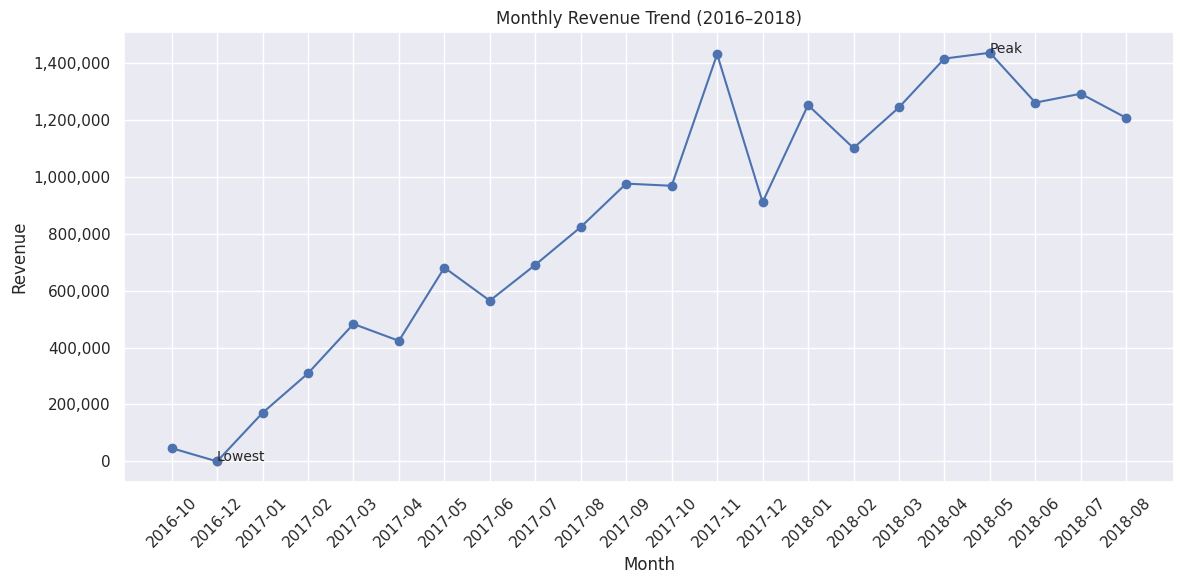

In [87]:
plt.figure(figsize=(12,6))

plt.plot(monthly_sales.index, monthly_sales.values, marker='o')

# Highlight peak
plt.scatter(peak_month, peak_value)
plt.text(peak_month, peak_value, 'Peak', fontsize=10)

# Highlight lowest
plt.scatter(lowest_month, lowest_value)
plt.text(lowest_month, lowest_value, 'Lowest', fontsize=10)

plt.title("Monthly Revenue Trend (2016–2018)")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()


- Revenue meningkat secara konsisten hingga mencapai puncak pada {peak_month}.
- Penurunan terendah terjadi pada {lowest_month}.
- Pola ini menunjukkan adanya seasonality, terutama menjelang akhir tahun.

### Pertanyaan 3:

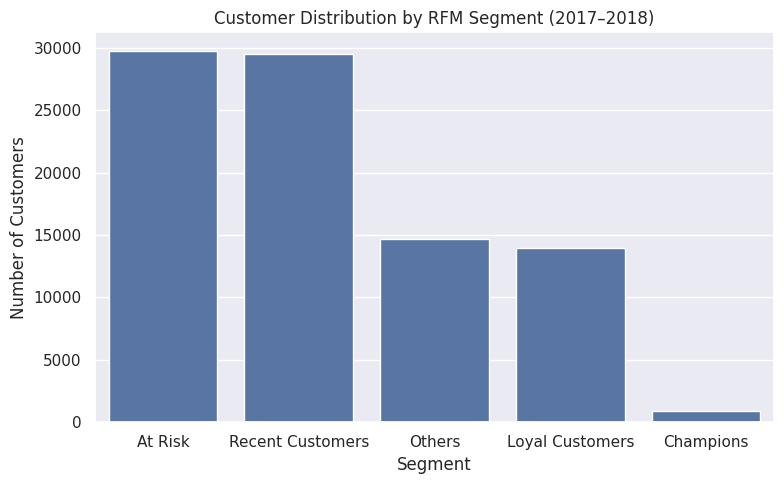

In [94]:
# Distribusi customer
plt.figure(figsize=(8,5))
sns.barplot(
    x=segment_counts.index,
    y=segment_counts.values
)

plt.title("Customer Distribution by RFM Segment (2017–2018)")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()



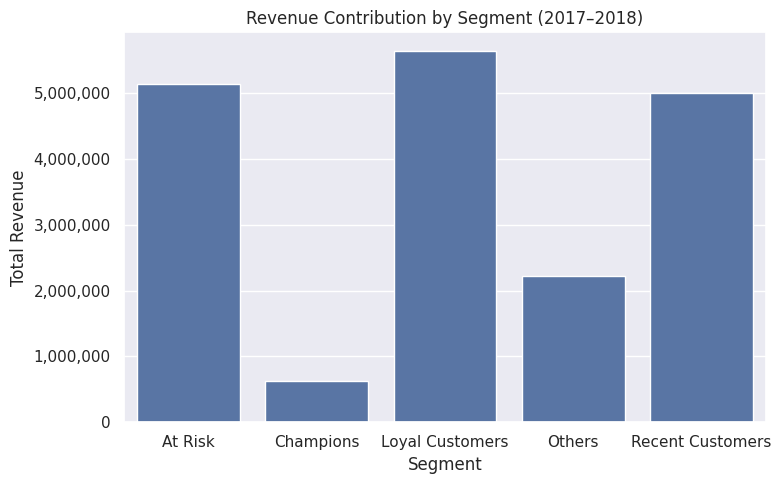

In [95]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=segment_revenue.index,
    y=segment_revenue.values
)

plt.title("Revenue Contribution by Segment (2017–2018)")
plt.xlabel("Segment")
plt.ylabel("Total Revenue")

plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()


**Insight:**
- Sebagian besar pelanggan berada dalam segmen “Others”, yang menunjukkan bahwa mayoritas pelanggan memiliki frekuensi transaksi rendah dan nilai pembelian kecil. Hal ini mengindikasikan bahwa bisnis didominasi oleh one-time buyers atau low engagement users, sehingga lifetime value pelanggan masih rendah.
- Meskipun jumlahnya relatif kecil, segmen “Champions” dan “Loyal Customers” memberikan kontribusi revenue yang paling besar. Ini menunjukkan adanya ketimpangan kontribusi antar segmen, di mana pelanggan dengan frekuensi tinggi dan monetary tinggi menjadi driver utama revenue.
- Segmen “At Risk” mengindikasikan pelanggan yang sebelumnya aktif namun sudah lama tidak melakukan transaksi (recency tinggi). Jika tidak segera ditangani, segmen ini berpotensi menyebabkan penurunan revenue di masa depan akibat churn.
- Secara keseluruhan, distribusi segmen menunjukkan bahwa bisnis memiliki customer base yang besar namun kualitas engagement rendah. Revenue saat ini masih bergantung pada sebagian kecil pelanggan aktif, sementara mayoritas pelanggan belum berhasil dikonversi menjadi repeat buyers.

## Conclusion

1. Distribusi kontribusi revenue menunjukkan bahwa revenue tidak terkonsentrasi pada segelintir pelanggan. Top 10 customers hanya berkontribusi sekitar 2.06%, Top 100 customers hanya sekitar 6.20%, Untuk mencapai 80% revenue, dibutuhkan sekitar 37.229 pelanggan. Hal ini mengindikasikan bahwa bisnis memiliki long-tail distribution, di mana sebagian besar revenue berasal dari banyak pelanggan dengan kontribusi kecil, bukan dari high-value customers saja. Berbeda dengan pola Pareto klasik (80/20), pada dataset ini ketergantungan terhadap top customers relatif rendah. Rekomendasi yang dapat diberikan adalah dengann fokus pada customer acquisition & retention mass market, bukan hanya VIP. Tingkatkan repeat purchase melalui promo bundling, diskon transaksi kedua, email remarketing. Gunakan strategi personalization ringan (bukan eksklusif) karena mayoritas pelanggan low–mid value dan yang terakhir optimalkan UX dan checkout flow untuk meningkatkan conversion rate
2. Revenue menunjukkan tren meningkat secara konsisten dari 2016 hingga 2018, dengan: Peak revenue terjadi pada: {peak_month} dan lowest revenue terjadi pada: {lowest_month}. Pola ini menunjukkan adanya seasonality, terutama peningkatan pada periode akhir tahun yang kemungkinan dipengaruhi oleh campaign promosi, event diskon besar, dan perilaku belanja musiman. Setelah mencapai puncak, revenue tetap berada pada level tinggi, yang menunjukkan pertumbuhan bisnis yang stabil. Rekomendasi yang dpaat diberikan dengan maksimalkan campaign marketing menjelang peak season (Q4 / akhir tahun). Perusahaan juga harus menyiapkan strategi seperti flash sale, campaign payday, limited-time, dan discount. Rekomendasi lainnya adalah  dengan meningkatkan  investasi ads pada periode dengan ROI historis tinggi.
3. Hasil segmentasi pelanggan berdasarkan metode RFM menunjukkan bahwa mayoritas pelanggan berada pada segmen “Others”, yang mengindikasikan rendahnya tingkat engagement, frekuensi transaksi, dan nilai pembelian. Sementara itu, segmen “Champions” dan “Loyal Customers” memiliki jumlah yang lebih kecil namun memberikan kontribusi revenue terbesar. Di sisi lain, segmen “At Risk” menunjukkan adanya pelanggan yang sebelumnya aktif namun mulai tidak melakukan transaksi dalam periode terbaru. Temuan ini menunjukkan bahwa bisnis memiliki basis pelanggan yang besar namun tingkat loyalitas masih rendah, serta ketergantungan yang cukup tinggi terhadap pelanggan bernilai tinggi (high-value customers) sebagai penyumbang utama revenue.

    Berdasarkan hasil segmentasi RFM, rekomendasi yang dapat diberikan adalah  perlu foku yang berbeda pada setiap kelompok pelanggan. Untuk segmen Champions dan Loyal Customers, perusahaan perlu memprioritaskan upaya retensi karena segmen ini memberikan kontribusi revenue terbesar. Strategi yang dapat dilakukan meliputi penerapan program loyalitas seperti pemberian poin, cashback, atau membership eksklusif, serta penawaran yang dipersonalisasi berdasarkan riwayat pembelian untuk menjaga engagement dan mencegah churn. Pada segmen At Risk, fokus utama adalah mengaktifkan kembali pelanggan yang mulai tidak bertransaksi melalui kampanye re-engagement seperti pemberian diskon khusus, pengiriman email atau notifikasi pengingat, serta rekomendasi produk yang relevan dengan preferensi sebelumnya. Sementara itu, untuk segmen Others yang merupakan mayoritas pelanggan, strategi diarahkan pada peningkatan frekuensi transaksi dan engagement. Hal ini dapat dilakukan dengan memberikan insentif pembelian awal seperti diskon untuk transaksi kedua, mengoptimalkan pengalaman pengguna terutama pada proses checkout, serta menyediakan rekomendasi produk yang sederhana namun relevan untuk mendorong terjadinya repeat purchase. Dengan pendekatan yang tersegmentasi ini, perusahaan dapat meningkatkan loyalitas pelanggan, mengurangi potensi churn, dan mengoptimalkan pertumbuhan revenue secara berkelanjutan.